# ASMC Method Tutorial

In this file we exemplify the workflow to use the `polynomial_sampler.py` module on a toy-model potential.

1. First we obtain a set of 10_000 numerical minima to the potential $V(x) = (x^2 + y^2 -1)^2$, stored as a (10_000, 2)-array
2. Using SparsePolynomialSampler, the locus $x^2 + y^2 = 1$ is reconstructed

In [1]:
# Importing packages
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from ASMC import SparsePolynomialSampler

from typing import Callable, Optional

## Moduli Space Sampling -- Gradient Descent

In [2]:
def grad_norm_squared(
        V: Callable[[tf.Tensor], tf.Tensor],
        x: tf.Tensor,
        non_zero: Optional[list] = None,
        factor: float=1.0):
    """
    Compute the squared L2 norm of the gradient of V wrt x, 
    evaluated on x with only `non_zero` indices active.

    Parameters
    ----------
    V : callable
        Function mapping x to outputs (batch_size, 1).
    x : tf.Tensor
        Input tensor of shape (batch_size, n_vars).
    non_zero : list of int
        Indices of x to keep; others are zeroed. Takes all indices by default.
    factor : float, optional
        Scaling factor for the squared gradient norm.

    Returns
    -------
    tf.Tensor
        Scaled squared gradient norm of shape (batch_size,).
    """
    n_vars = x.shape[1]

    if non_zero is None or len(non_zero) == 0:
        non_zero = list(range(n_vars))

    mask = tf.constant([1.0 if i in non_zero else 0.0 for i in range(n_vars)], dtype=x.dtype)
    
    with tf.GradientTape() as tape:
        tape.watch(x)
        x_masked = x * mask  
        y = V(x_masked)

    gradients = tape.gradient(y, x)
    return factor * tf.reduce_sum(gradients**2, axis=1)

In [3]:
# Definition of Potential
def V_Higgs(x):
    x1, x2 = tf.split(x, 2, axis=1)
    return (x1**2 + x2**2 -1)**2

# Randomly initialize the points
n_points = 10_000
x_2d = tf.Variable(4*np.random.rand(n_points, 2)-2, dtype=tf.float32)

history_2d = []
history_loss_2d = []

# Definition of optimizer
alpha = 1e-3
optimizer = tf.keras.optimizers.Adam(learning_rate=alpha)

# Learning loop 
for step in range(2000):  
    with tf.GradientTape() as tape:       
        grad_norm_squared_this_step = grad_norm_squared(V_Higgs, x_2d)
        # minimize ||∇V||^2 for all points
        loss = tf.reduce_sum(grad_norm_squared_this_step)
    
    
    # Compute ||∇V||^2 with respect to x
    gradients = tape.gradient(loss, [x_2d])

    # Update of the optimizer at certain steps
    if step in [250,500,750,1000]:
       optimizer = tf.optimizers.Adam(learning_rate=alpha)
    elif step in [1250,1500,1750]:
       optimizer = tf.optimizers.Adam(learning_rate=alpha/10)
    elif step in [6000]:
       optimizer = tf.optimizers.Adam(learning_rate=alpha/100)
    
    # Apply gradient descent to all points
    optimizer.apply_gradients(zip(gradients, [x_2d]))
    
    history_2d.append(loss)
    history_loss_2d.append(optimizer.learning_rate.numpy())
    
    if step % 10 == 0:

        current_lr = optimizer.learning_rate.numpy()
        print(f"""Step {step}: ||∇V||^2 = {loss.numpy()} with learning rate {current_lr}""")
        
    if np.log(loss.numpy())/np.log(10)<-10: 
        print("Converged enough") 
        print(f"Step {step}: ||∇V||^2 = {loss.numpy()}")
        break

Step 0: ||∇V||^2 = 4166641.5 with learning rate 0.0010000000474974513
Step 10: ||∇V||^2 = 3986460.0 with learning rate 0.0010000000474974513
Step 20: ||∇V||^2 = 3814045.0 with learning rate 0.0010000000474974513
Step 30: ||∇V||^2 = 3649874.5 with learning rate 0.0010000000474974513
Step 40: ||∇V||^2 = 3494039.0 with learning rate 0.0010000000474974513
Step 50: ||∇V||^2 = 3346338.0 with learning rate 0.0010000000474974513
Step 60: ||∇V||^2 = 3206410.5 with learning rate 0.0010000000474974513
Step 70: ||∇V||^2 = 3073828.5 with learning rate 0.0010000000474974513
Step 80: ||∇V||^2 = 2948151.75 with learning rate 0.0010000000474974513
Step 90: ||∇V||^2 = 2828954.5 with learning rate 0.0010000000474974513
Step 100: ||∇V||^2 = 2715835.5 with learning rate 0.0010000000474974513
Step 110: ||∇V||^2 = 2608419.75 with learning rate 0.0010000000474974513
Step 120: ||∇V||^2 = 2506360.5 with learning rate 0.0010000000474974513
Step 130: ||∇V||^2 = 2409333.5 with learning rate 0.0010000000474974513
S

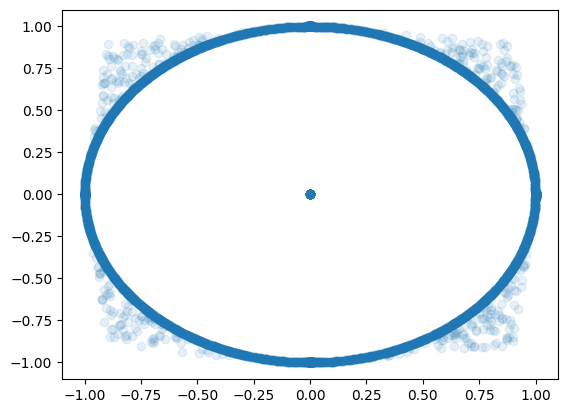

In [4]:
x_np = x_2d.numpy()
plt.scatter(*x_np.T, alpha=0.1)
plt.show()

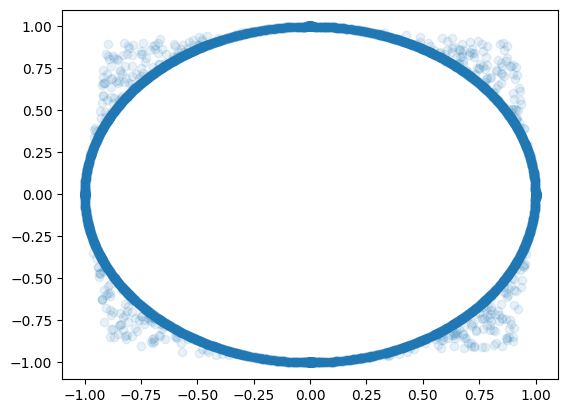

In [5]:
# Filtered sample (exclude the origin)
norms = np.linalg.norm(x_np, axis=1)
x_filtered = x_np[norms > 1e-5]

plt.scatter(*x_filtered.T, alpha=0.1)
plt.show()

## Manifold Reconstruction

In [6]:
# Initialize sampler
sampler = SparsePolynomialSampler(
    data_x=x_filtered,
    max_degree=5,
    num_vars=2,
    max_num_monomials=10,
)

Pre-compute multiply/divide transitions...
  Average of multiply transitions: 1.43
  Average of divide transitions: 1.43
Number of possible terms in the polynomial: 21


In [7]:
# ASMC optimization
all_out = sampler.run_annealing_is(
    n_iter=1000,       
    n_particles=1000,  
    verbose=True,
)

Iteration 1/1000, 	Beta: 1e-06, 	Acceptance rate: 0.97, 	ESS: 999.67/1000, 	Best loss: 978.944380,	Elapsed time: 0.81s, 	Prob (0.2, 0.2, 0.2, 0.2, 0.2), 	Best pol : 0.0579*x1 + 0.0568*x1^2*x2^2 + 0.0002*x1^3*x2 + 0.5410*x1*x2^4 + 1.5243*x1^2*x2^3 + 1.1260*x1^3*x2^2 - 0.0237*x1^4*x2
Iteration 2/1000, 	Beta: 1.5e-06, 	Acceptance rate: 0.95, 	ESS: 860.97/1000, 	Best loss: 978.944380,	Elapsed time: 0.94s, 	Prob (0.2, 0.2, 0.2, 0.2, 0.2), 	Best pol : 0.0579*x1 + 0.0568*x1^2*x2^2 + 0.0002*x1^3*x2 + 0.5410*x1*x2^4 + 1.5243*x1^2*x2^3 + 1.1260*x1^3*x2^2 - 0.0237*x1^4*x2
Iteration 3/1000, 	Beta: 2.3e-06, 	Acceptance rate: 0.96, 	ESS: 742.73/1000, 	Best loss: 978.944380,	Elapsed time: 1.05s, 	Prob (0.2, 0.2, 0.2, 0.2, 0.2), 	Best pol : -0.1514*x2^2 + 0.1639*x1*x2 - 0.0155*x1^2 - 1.6014*x1*x2^2 + 0.0856*x2^4 + 0.4432*x1^3*x2 + 0.9759*x1*x2^4 + 0.2369*x1^2*x2^3
Iteration 4/1000, 	Beta: 3.4e-06, 	Acceptance rate: 0.96, 	ESS: 708.26/1000, 	Best loss: 978.944380,	Elapsed time: 1.17s, 	Prob (0.2, 0.2, 

In [8]:
best_coeffs = all_out[0]
bc_trunc = sampler.apply_coefficient_threshold(best_coeffs)
res, loss = sampler.local_search(best_coeffs,n_steps=1000,use_reg=False)

In [9]:
sampler.polynomial_to_string(res)
sampler.min_coeff_threshold = 1e-3
res_trunc = sampler.apply_coefficient_threshold(res)
nonzero_indices = np.nonzero(res_trunc)
coeff_min = np.min(abs(res_trunc[nonzero_indices]))

print(sampler.polynomial_to_string(res_trunc/coeff_min))

180.9987*x2 - 1584.8998*x2^3 + 478.3636*x1^2*x2 - 2.9830*x1*x2^3 - x1^2*x2^2 + 1407.7432*x2^5 + 663.0612*x1^2*x2^3 - 635.1909*x1^4*x2
